In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from lightgbm import LGBMRegressor

In [3]:
df = pd.read_parquet('BTC_1m_OHLCV.parquet')
df.head()

,datetime,timestamp_ms,open,high,low,close,volume,turnover
0,2020-03-25 10:36:00+00:00,1585132560000,6500.0,6500.0,6500.0,6500.0,0.001,6.5
1,2020-03-25 10:37:00+00:00,1585132620000,6500.0,6500.0,6500.0,6500.0,0.000,0.0
2,2020-03-25 10:38:00+00:00,1585132680000,6500.0,6500.0,6500.0,6500.0,0.000,0.0
3,2020-03-25 10:39:00+00:00,1585132740000,6500.0,6500.0,6500.0,6500.0,0.000,0.0
4,2020-03-25 10:40:00+00:00,1585132800000,6500.0,6500.0,6500.0,6500.0,0.000,0.0


In [4]:
df["datetime"] = pd.to_datetime(df["datetime"], utc=True)
df = df.sort_values("datetime").set_index("datetime")
df = df[["open", "high", "low", "close", "volume", "turnover"]].astype(float)
df["r"] = np.log(df["close"]).diff()
df["r2"] = df["r"] ** 2
h = pd.DataFrame(index=df.resample("1h").size().index)
h["n_minutes"] = df["close"].resample("1h").count()
h["rv"] = df["r2"].resample("1h").sum()
h["log_rv"] = np.log(h["rv"] + 1e-12)
ohlcv = df.resample("1h").agg({
    "open": "first",
    "high": "max",
    "low": "min",
    "close": "last",
    "volume": "sum",
    "turnover": "sum"})
h["ret"] = np.log(ohlcv["close"]).diff()
h["abs_ret"] = h["ret"].abs()
h["hl_range"] = np.log(ohlcv["high"] / ohlcv["low"])
h["oc_range"] = np.abs(np.log(ohlcv["close"] / ohlcv["open"]))
h["log_volume"] = np.log1p(ohlcv["volume"])
h["log_turnover"] = np.log1p(ohlcv["turnover"])
h["log_dollar_volume"] = np.log1p(ohlcv["close"] * ohlcv["volume"])
x = pd.DataFrame(index=h.index)
for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    x[f"log_rv_lag_{lag}h"] = h["log_rv"].shift(lag)
for window in [3, 6, 12, 24, 72, 168, 720]:
    x[f"log_rv_mean_{window}h"] = h["log_rv"].shift(1).rolling(window).mean()
for window in [24, 72, 168, 720]:
    x[f"log_rv_std_{window}h"] = h["log_rv"].shift(1).rolling(window).std()
for span in [6, 12, 24, 72, 168]:
    x[f"log_rv_ewm_{span}h"] = h["log_rv"].shift(1).ewm(span=span, adjust=False).mean()
for window in [24, 168]:
    mean = h["log_rv"].shift(2).rolling(window).mean()
    std = h["log_rv"].shift(2).rolling(window).std()
    x[f"log_rv_zscore_{window}h"] = (h["log_rv"].shift(1) - mean) / std
for lag in [1, 2, 3, 6, 12, 24]:
    x[f"ret_lag_{lag}h"] = h["ret"].shift(lag)
for lag in [1, 3, 6, 24]:
    x[f"abs_ret_lag_{lag}h"] = h["abs_ret"].shift(lag)
for window in [6, 24, 168]:
    x[f"abs_ret_mean_{window}h"] = h["abs_ret"].shift(1).rolling(window).mean()
for lag in [1, 24, 168]:
    x[f"hl_range_lag_{lag}h"] = h["hl_range"].shift(lag)
    x[f"oc_range_lag_{lag}h"] = h["oc_range"].shift(lag)
for window in [24, 168]:
    x[f"hl_range_mean_{window}h"] = h["hl_range"].shift(1).rolling(window).mean()
    x[f"oc_range_mean_{window}h"] = h["oc_range"].shift(1).rolling(window).mean()
for lag in [1, 2, 3, 6, 12, 24, 168]:
    x[f"log_volume_lag_{lag}h"] = h["log_volume"].shift(lag)
for window in [24, 168]:
    x[f"log_volume_mean_{window}h"] = h["log_volume"].shift(1).rolling(window).mean()
    x[f"log_volume_std_{window}h"] = h["log_volume"].shift(1).rolling(window).std()
for lag in [1, 24, 168]:
    x[f"log_turnover_lag_{lag}h"] = h["log_turnover"].shift(lag)
    x[f"log_dollar_volume_lag_{lag}h"] = h["log_dollar_volume"].shift(lag)
for window in [24, 168]:
    x[f"log_turnover_mean_{window}h"] = h["log_turnover"].shift(1).rolling(window).mean()
    x[f"log_dollar_volume_mean_{window}h"] = h["log_dollar_volume"].shift(1).rolling(window).mean()
hour = x.index.hour
dow = x.index.dayofweek
x["hour_sin"] = np.sin(2 * np.pi * hour / 24)
x["hour_cos"] = np.cos(2 * np.pi * hour / 24)
x["dow_sin"] = np.sin(2 * np.pi * dow / 7)
x["dow_cos"] = np.cos(2 * np.pi * dow / 7)
x["is_weekend"] = (dow >= 5).astype(int)
x["is_asia_session"] = ((hour >= 0) & (hour < 8)).astype(int)
x["is_europe_session"] = ((hour >= 7) & (hour < 16)).astype(int)
x["is_us_session"] = ((hour >= 13) & (hour < 22)).astype(int)
x["is_eu_us_overlap"] = ((hour >= 13) & (hour < 16)).astype(int)
q10_168 = h["log_rv"].shift(2).rolling(168).quantile(0.10)
q90_168 = h["log_rv"].shift(2).rolling(168).quantile(0.90)
x["is_low_vol_168h"] = (h["log_rv"].shift(1) < q10_168).astype(int)
x["is_high_vol_168h"] = (h["log_rv"].shift(1) > q90_168).astype(int)
x["log_rv_lag1_x_us_session"] = x["log_rv_lag_1h"] * x["is_us_session"]
x["log_rv_lag1_x_weekend"] = x["log_rv_lag_1h"] * x["is_weekend"]
x["log_volume_lag1_x_us_session"] = x["log_volume_lag_1h"] * x["is_us_session"]
x["abs_ret_lag1_x_us_session"] = x["abs_ret_lag_1h"] * x["is_us_session"]
dataset = x.copy()
dataset["target_log_rv"] = h["log_rv"]
dataset["target_rv"] = h["rv"]
dataset = dataset[h["n_minutes"] == 60]
dataset = dataset.replace([np.inf, -np.inf], np.nan).dropna()
X = dataset.drop(columns=["target_log_rv", "target_rv"])
y = dataset["target_log_rv"]
dataset.to_parquet("BTC_1h_logRV_ML_dataset.parquet")

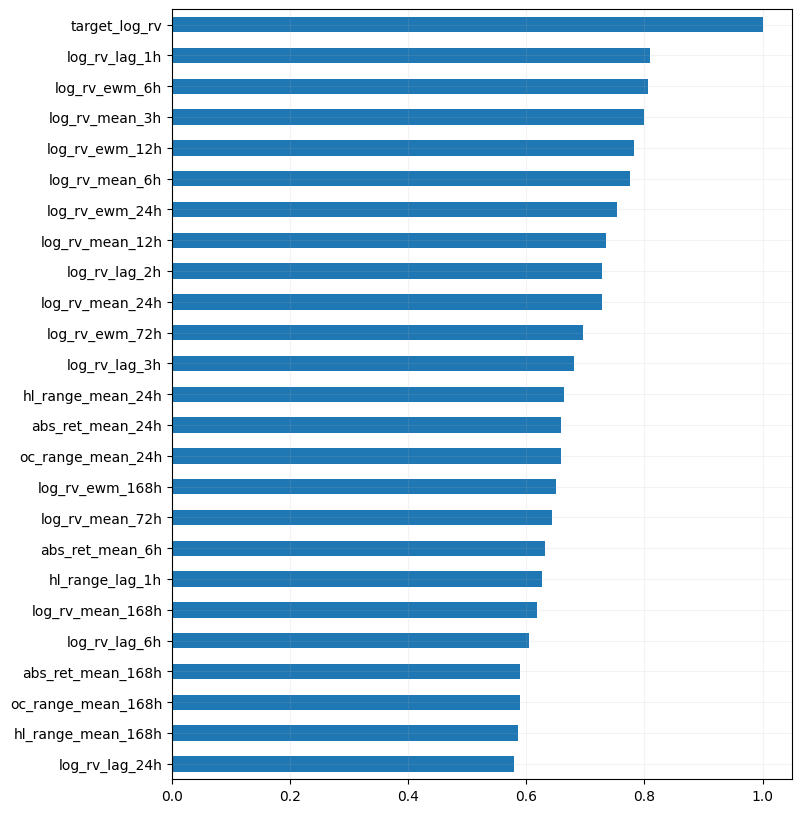

In [6]:
corr = dataset.corr(numeric_only=True)["target_log_rv"]
corr = corr.drop("target_rv").sort_values()
corr.tail(25).plot.barh(figsize=(8, 10))
plt.grid(alpha=0.15)
plt.show()

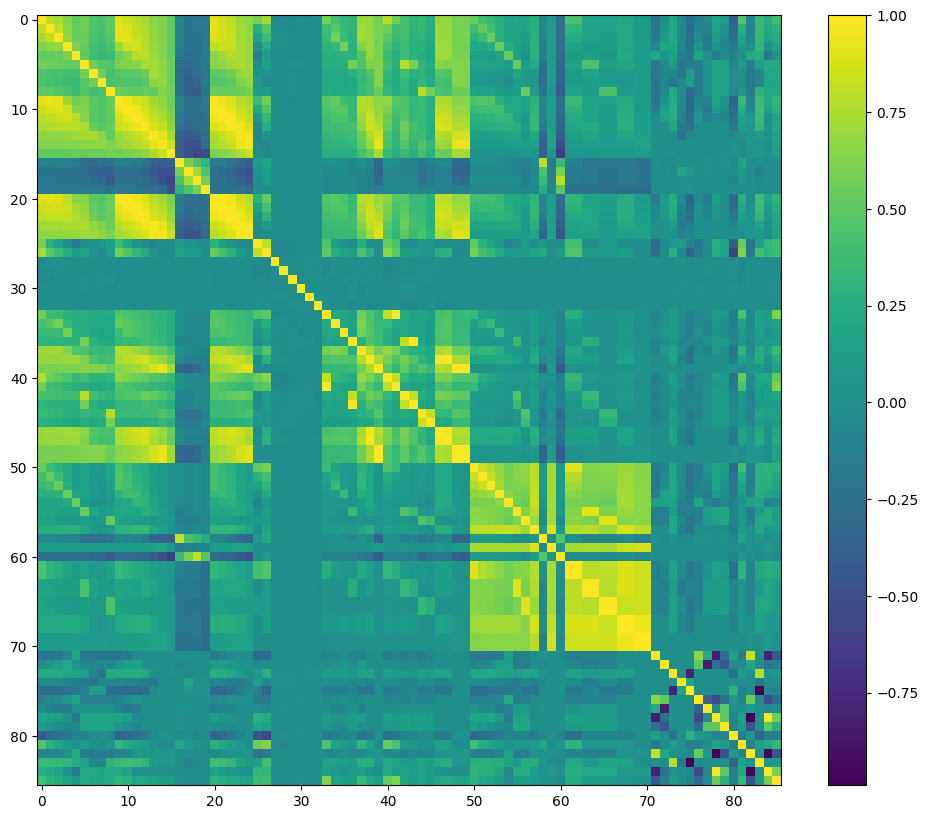

In [7]:
corr_matrix = X.corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.show()

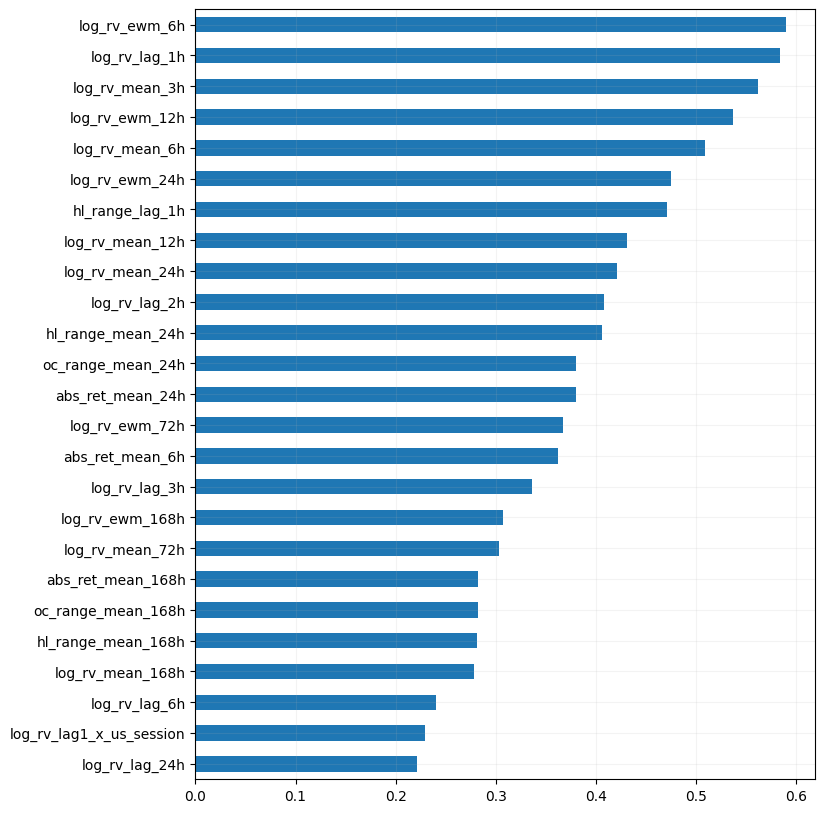

In [9]:
mi = mutual_info_regression(
    X.fillna(0),
    y)
mi = pd.Series(mi, index=X.columns)
mi.sort_values().tail(25).plot.barh(figsize=(8, 10))
plt.grid(alpha=0.15)
plt.show()

In [10]:
split = int(len(dataset) * 0.7)
train = dataset.iloc[:split]
test = dataset.iloc[split:]

In [11]:
comparison = pd.DataFrame({
    "train_mean": train.mean(),
    "test_mean": test.mean(),
    "train_std": train.std(),
    "test_std": test.std()
})

comparison.head(20)

,train_mean,test_mean,train_std,test_std
log_rv_lag_1h,-10.867448,-11.162399,1.403430,1.109428
log_rv_lag_2h,-10.867419,-11.162434,1.403426,1.109432
log_rv_lag_3h,-10.867416,-11.162455,1.403426,1.109425
log_rv_lag_6h,-10.867404,-11.162547,1.403424,1.109456
log_rv_lag_12h,-10.867373,-11.162203,1.403442,1.109446
log_rv_lag_24h,-10.867041,-11.162182,1.403572,1.109754
log_rv_lag_48h,-10.866910,-11.162112,1.403539,1.109660
log_rv_lag_72h,-10.867100,-11.160833,1.403646,1.109067
log_rv_lag_168h,-10.868917,-11.150586,1.403718,1.108435
log_rv_mean_3h,-10.867428,-11.162429,1.297170,1.022140


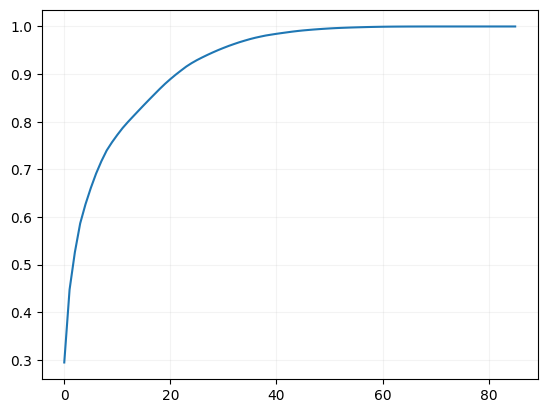

In [14]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA().fit(X_scaled)
explained = np.cumsum(pca.explained_variance_ratio_)
plt.plot(explained)
plt.grid(alpha=0.15)
plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004374 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19193
[LightGBM] [Info] Number of data points in the train set: 37013, number of used features: 86
[LightGBM] [Info] Start training from score -10.867434


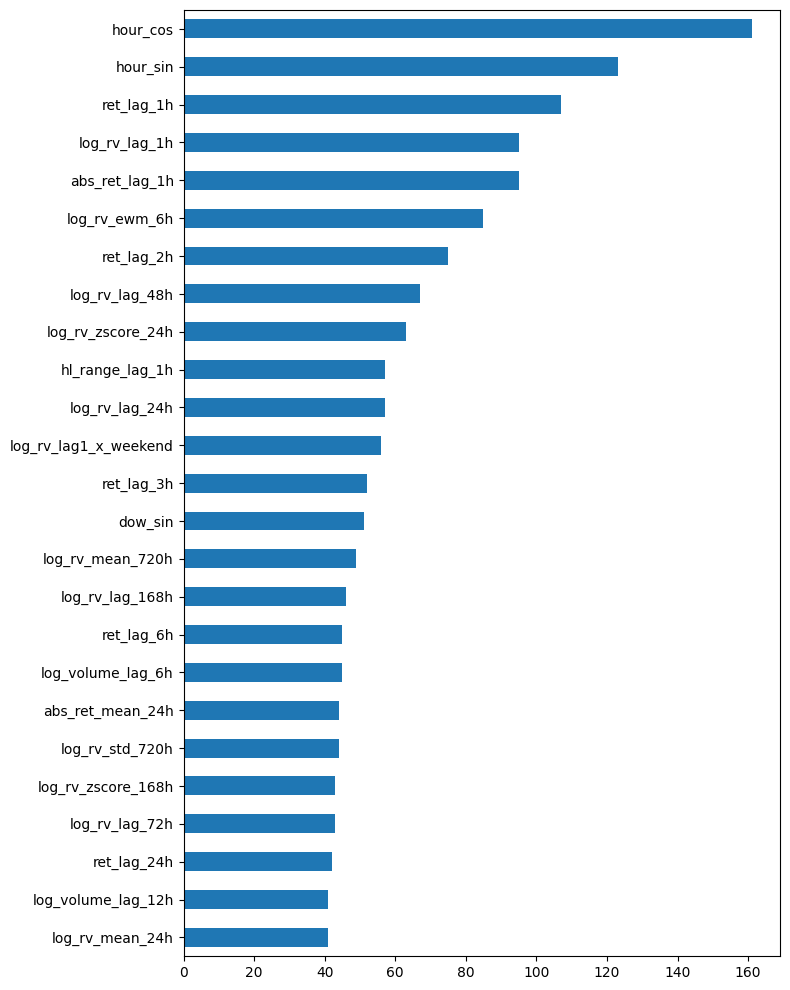

In [21]:
model = LGBMRegressor()
model.fit(
    X.iloc[:split],
    y.iloc[:split])
importance = pd.Series(
    model.feature_importances_,
    index=X.columns)
plt.figure(figsize=(8, 10))
importance.sort_values().tail(25).plot.barh()
plt.tight_layout()
plt.savefig(
    "importanceLGBM.png",
    dpi=300,
    bbox_inches="tight")
plt.show()

In [19]:
dataset.shape

(52876, 88)